<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/2%20K-Nearest%20Neigbours%20Regression%20(for%20Slides).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

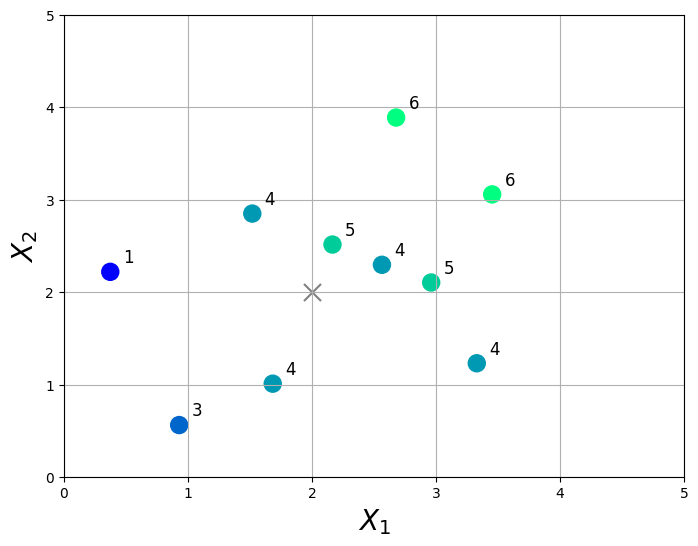

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Setting a random seed for reproducibility
np.random.seed(24)

# Generate 10 random data points centered around (2, 2)
data_points = np.array([[2, 2]]) + np.random.randn(10, 2)  # Adding normally distributed noise centered at 2
labels = np.round(1.75*data_points[:, 0] + np.random.normal(0, 1, 10))  # Regression labels as integers

# New point for prediction
new_point = np.array([2, 2])

# Create the plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
plt.scatter(data_points[:, 0], data_points[:, 1], c=labels, cmap='winter', s=150, marker='o')
plt.scatter(new_point[0], new_point[1], color='grey', s=150, marker='x')  # Highlight new point

for i in range(10) :
    ax.text(data_points[i, 0]+0.1, data_points[i,1]+0.1, int(labels[i]), fontsize=12)

# Adding labels, title, and legend
#plt.colorbar(label='Target value')
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([0, 5, 0, 5])

# Show grid
plt.grid(True)

# Display the plot
plt.show()



In [17]:
labels

array([2., 2., 2., 3., 0., 4., 3., 3., 4., 3.])

In [ ]:
from sklearn.metrics import pairwise_distances
from collections import Counter

def kNN_Classify(new_point, data_points, labels, k, distance_metric='euclidean'):
    # Step 1: Calculate distances using pairwise_distances
    distances = pairwise_distances(data_points, new_point, metric=distance_metric).ravel()

    # Step 2 & 3: Sort distances and select k nearest neighbors
    k_nearest_neighbors_indices = np.argsort(distances)[:k]
    k_nearest_labels = labels[k_nearest_neighbors_indices]

    # Step 4: Perform majority vote
    most_common = Counter(k_nearest_labels).most_common(1)

    # Step 5: Determine the predicted class
    predicted_class = most_common[0][0]

    return predicted_class

In [ ]:
# Example usage
data_points = np.array([[1, 2], [2, 3], [3, 4], [6, 7], [7, 8], [8, 9]])
labels = np.array([0, 0, 0, 1, 1, 1])  # 0 and 1 are class labels
new_point = np.array([[4, 5]])
k = 3
distance_metric = 'euclidean'  # Can be 'euclidean', 'manhattan', 'cosine', etc.

# Classify the new point
predicted_class = kNN_Classify(new_point, data_points, labels, k, distance_metric)
print("Predicted Class:", predicted_class)

Predicted Class: 0


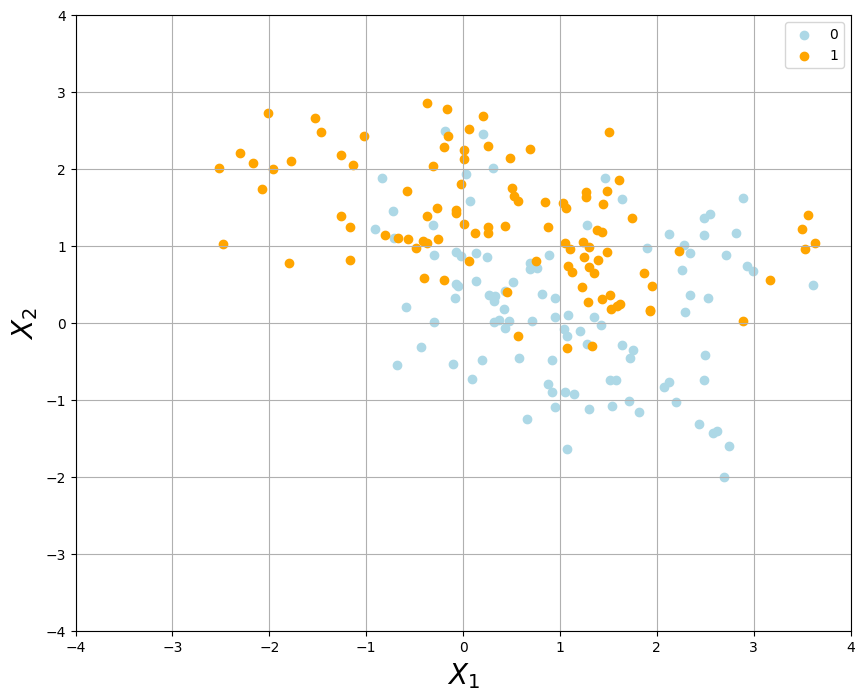

In [ ]:
import pandas as pd

# URL for our dataset, mixture-example.csv
URL = "https://drive.google.com/file/d/1l0QDFXeyrelvjXlyhnj4ppP_SSTABIKp/view?usp=sharing"
FILE_PATH = "https://drive.google.com/uc?export=download&id=" + URL.split("/")[-2]

data = pd.read_csv(FILE_PATH)

# Filter data by labels
data_0 = data[data['Label'] == 0]
data_1 = data[data['Label'] == 1]

# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(data_0['X'], data_0['Y'], color='lightblue', label='0', marker='o')
plt.scatter(data_1['X'], data_1['Y'], color='orange', label='1', marker='o')

# Adding labels and legend
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-4, 4, -4, 4])
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Load the dataset
# data = pd.read_csv('/path/to/mixture-example.csv')  # Adjust path as necessary

# Separate features and labels
X = data[['X', 'Y']].values  # assuming 'X' and 'Y' are your features
y = data['Label'].values  # assuming 'Label' is your label column

# First, split the data into train (60%) and temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Then split the temp data into validation (50% of 40% => 20% of total) and test (remaining 50% of 40% => 20% of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Checking the proportion of each set
print("Training Set Size:", len(X_train))
print("Validation Set Size:", len(X_val))
print("Test Set Size:", len(X_test))


Training Set Size: 120
Validation Set Size: 40
Test Set Size: 40


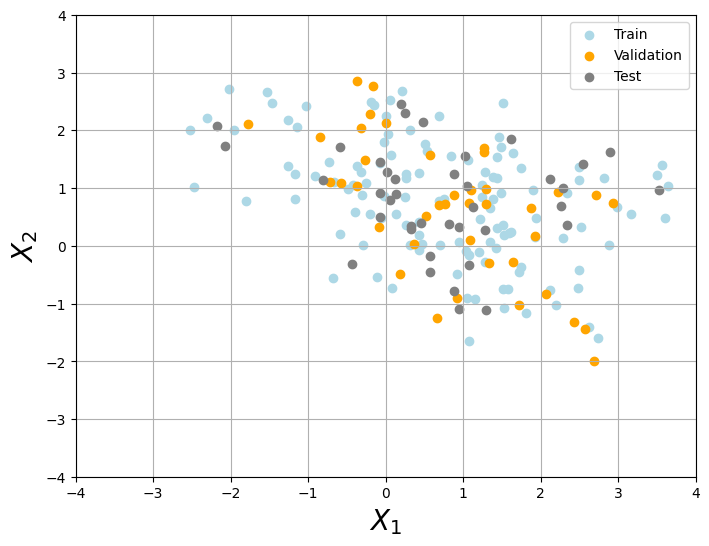

In [ ]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:,0], X_train[:,1], color='lightblue', label='Train', marker='o')
plt.scatter(X_val[:,0], X_val[:,1], color='orange', label='Validation', marker='o')
plt.scatter(X_test[:,0], X_test[:,1], color='grey', label='Test', marker='o')

# Adding labels and legend
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-4, 4, -4, 4])
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

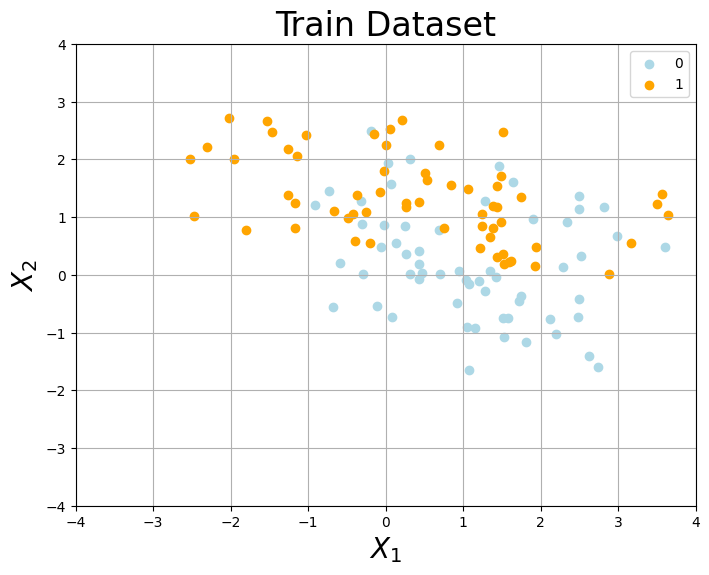

In [ ]:
# Plotting

X = X_train
y = y_train
title = "Train Dataset"

plt.figure(figsize=(8, 6))
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='lightblue', label='0', marker='o')
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='orange', label='1', marker='o')

# Adding labels and legend
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-4, 4, -4, 4])
plt.title(title, fontsize=24)
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define k and the distance metric
k = 5
distance_metric = 'euclidean'

# Create an instance of KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=k, metric=distance_metric)

# Fit the model on the training data
knn.fit(X_train, y_train)

# Predict the labels on the validation set
predictions = knn.predict(X_val)

# Calculate the accuracy of the predictions
accuracy = accuracy_score(y_val, predictions)
print("Accuracy of the k-NN classifier on the validation set:", accuracy)


Accuracy of the k-NN classifier on the validation set: 0.85


In [ ]:
from sklearn.metrics import pairwise_distances
from collections import Counter

def kNN_Classify(new_points, data_points, labels, k, distance_metric='euclidean'):
    predictions = []
    for new_point in new_points:
        # Calculate distances
        distances = pairwise_distances(data_points, [new_point], metric=distance_metric).ravel()

        # Get indices of k nearest neighbors
        k_nearest_indices = np.argsort(distances)[:k]
        k_nearest_labels = labels[k_nearest_indices]

        # Perform majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        predicted_class = most_common[0][0]
        predictions.append(predicted_class)

    return predictions

In [ ]:
from sklearn.metrics import accuracy_score

# Define k and the distance metric
k = 5
distance_metric = 'euclidean'

# Call the kNN_Classify function to predict the validation set
predictions = kNN_Classify(X_val, X_train, y_train, k, distance_metric)

# Calculate the accuracy of the predictions
accuracy = accuracy_score(y_val, predictions)
print("Accuracy of the k-NN classifier on the validation set:", accuracy)

Accuracy of the k-NN classifier on the validation set: 0.85


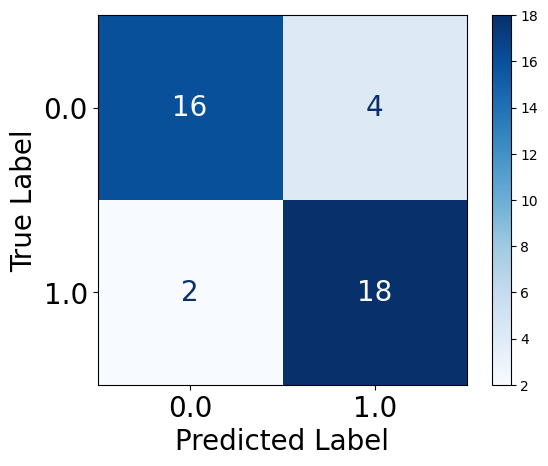

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fontsize = 20
ax = ConfusionMatrixDisplay.from_predictions(y_val, predictions, cmap=plt.cm.Blues)
#plt.plot()
for entries in ax.text_.ravel():
    entries.set_fontsize(fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel("Predicted Label", fontsize=fontsize)
plt.ylabel("True Label", fontsize=fontsize)
plt.show()


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
# Define your CustomKNNClassifier following scikit-learn conventions...

class CustomKNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X, y):
        self.X_train_ = X
        self.y_train_ = y
        return self

    def predict(self, X):
        # Your custom predict logic here
        y_pred = []
        for x in X:
            # Calculate distances
            distances = pairwise_distances(self.X_train_, [x], metric=self.distance_metric).ravel()

            # Get indices of k nearest neighbors
            k_nearest_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train_[k_nearest_indices]

            # Perform majority vote
            most_common = Counter(k_nearest_labels).most_common(1)
            predicted_class = most_common[0][0]
            y_pred.append(predicted_class)

        return np.array(y_pred)


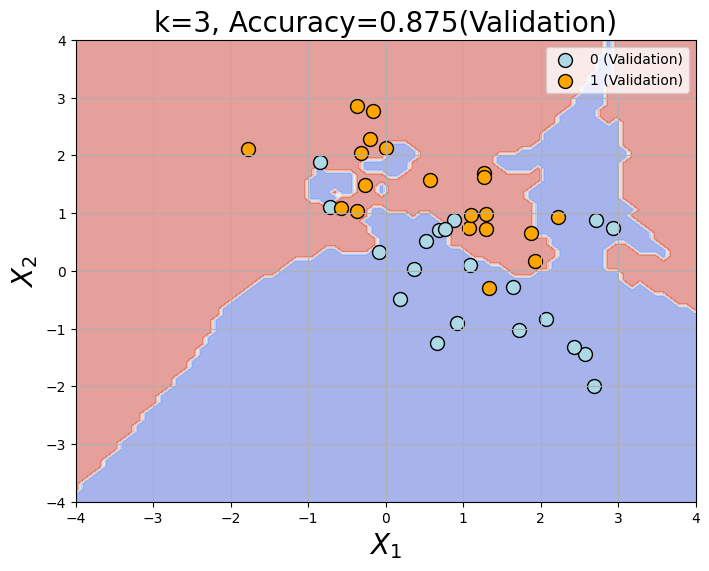

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay

k = 3
distance_metric = "euclidean"

xv, yv = np.meshgrid(np.linspace(-4,4,400), np.linspace(-4,4,400))

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    estimator=knn,
    X=np.vstack((xv.ravel(), yv.ravel())).T,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['0', '1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
#ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(X_val))))
ax.set_xlabel('$X_1$', fontsize=20)
ax.set_ylabel('$X_2$', fontsize=20)
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.axis([-4, 4, -4, 4])
plt.title("k=" + str(k) + ", Accuracy=" + str(accuracy_score(y_val, knn.predict(X_val))) + "(Validation)", fontsize=20)
plt.grid()
plt.show()

In [ ]:
xv, yv = np.meshgrid(np.linspace(-4,4,400), np.linspace(-4,4,400))
np.vstack((xv.ravel(), yv.ravel())).T

array([[-4.        , -4.        ],
       [-3.97994987, -4.        ],
       [-3.95989975, -4.        ],
       ...,
       [ 3.95989975,  4.        ],
       [ 3.97994987,  4.        ],
       [ 4.        ,  4.        ]])

In [ ]:
neighbours = np.arange(1,31)
validation_scores = []
train_scores = []
for k in neighbours :
    knn = CustomKNNClassifier(k=k, distance_metric="euclidean")
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)

    validation_scores.append(accuracy_score(y_val, knn.predict(X_val)))
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))

validation_scores = np.array(validation_scores)
train_scores = np.array(train_scores)

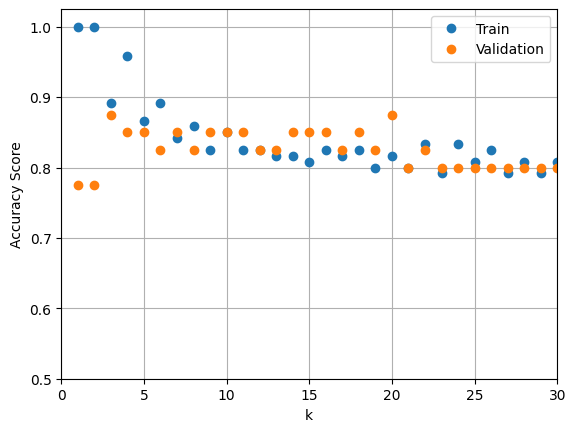

In [ ]:
plt.plot(neighbours, train_scores, 'o', label="Train")
plt.plot(neighbours, validation_scores, 'o', label="Validation")
plt.xlabel('k')
plt.ylabel('Accuracy Score')
plt.axis([0, 30, 0.5, 1.025])
plt.grid()
plt.legend()
plt.show()

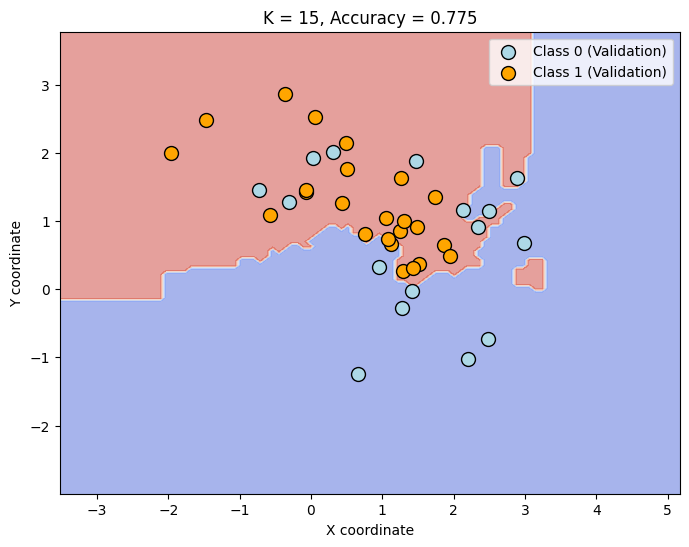

In [ ]:
k = 15
distance_metric = "manhattan"

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    knn,
    X_train,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['Class 0', 'Class 1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(X_val))))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.show()

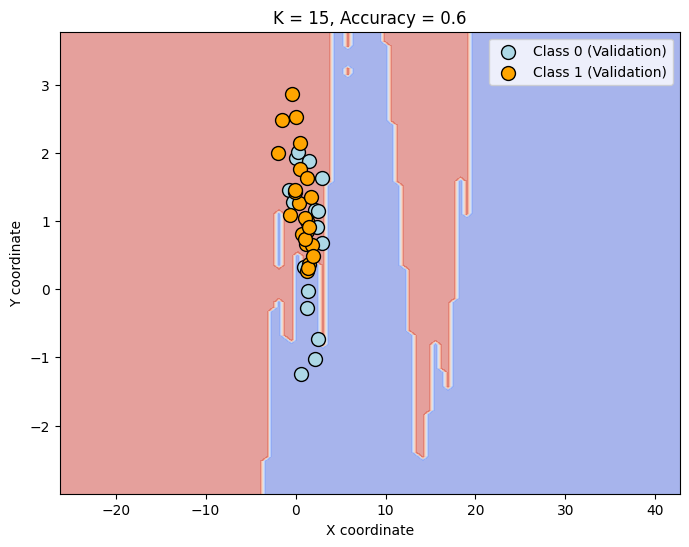

In [ ]:
k = 15
distance_metric = "euclidean"
scale = np.array([10, 1])

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(scale*X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    knn,
    scale*X_train,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['Class 0', 'Class 1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(scale*X_val))))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.show()

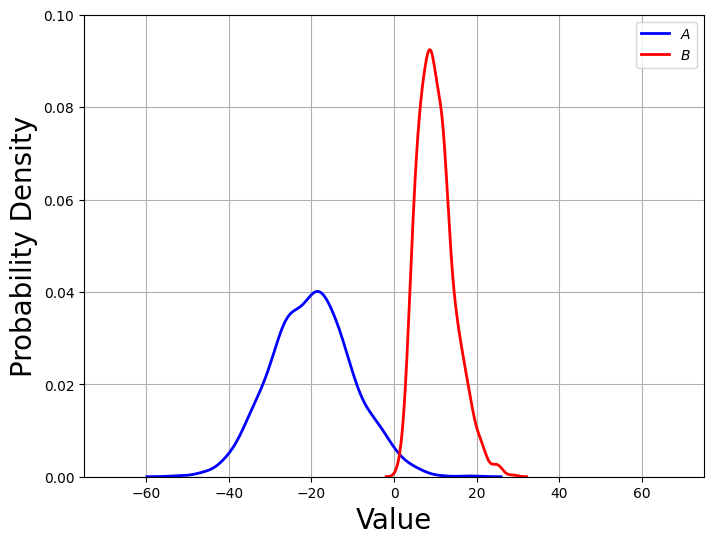

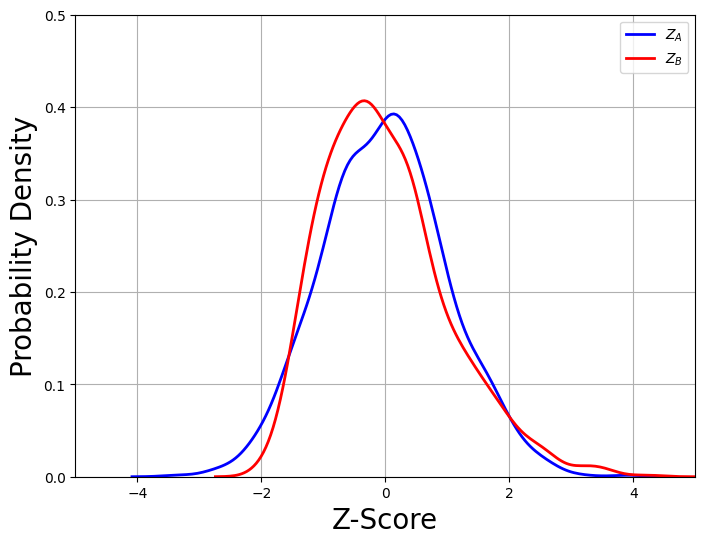

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate and standardize data
data_normal = np.random.normal(loc=-20, scale=10, size=1000)
data_gamma = np.random.gamma(shape=5, scale=2, size=1000)
z_normal = (data_normal - np.mean(data_normal)) / np.std(data_normal)
z_gamma = (data_gamma - np.mean(data_gamma)) / np.std(data_gamma)

# Plotting using seaborn for easier KDE
plt.figure(figsize=(8, 6))
sns.kdeplot(data_normal, label='$A$', color='blue', lw=2)
sns.kdeplot(data_gamma, label='$B$', color='red', lw=2)
plt.xlabel("Value", fontsize=20)
plt.ylabel("Probability Density", fontsize=20)
plt.axis([-75, 75, 0, 0.1])
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
sns.kdeplot(z_normal, label='$Z_{A}$', color='blue', lw=2)
sns.kdeplot(z_gamma, label='$Z_{B}$', color='red', lw=2)
plt.xlabel("Z-Score", fontsize=20)
plt.ylabel("Probability Density", fontsize=20)
plt.axis([-5, 5, 0, 0.5])
plt.legend()
plt.grid()
plt.show()


In [ ]:
np.mean(data_normal), np.std(data_normal), np.mean(data_gamma), np.std(data_gamma)

(-19.806679441776744, 9.787262077473542, 10.16331996051392, 4.401450303905136)

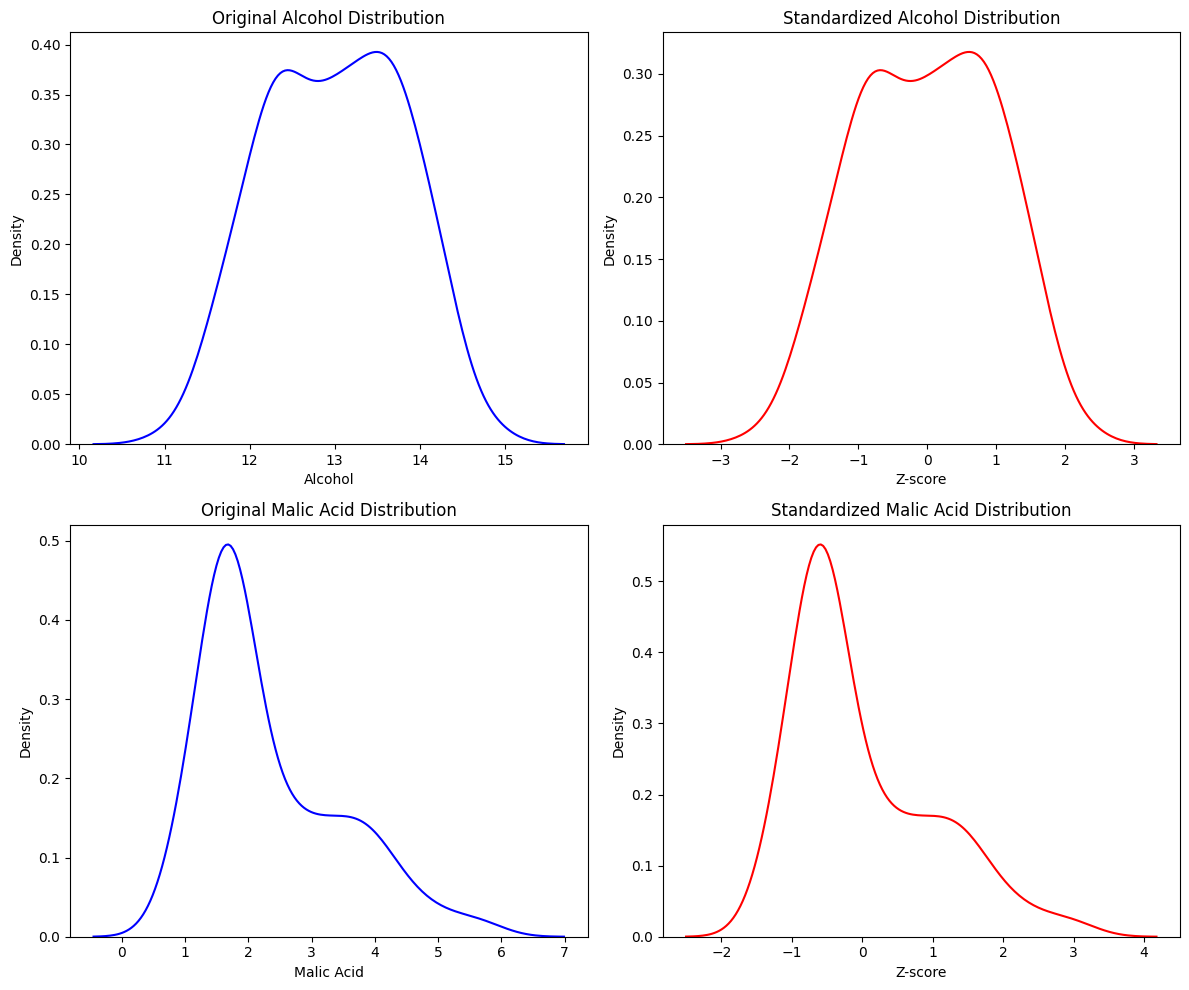

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a standard scaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up GridSearchCV to find the optimal k for k-NN
param_grid = {'n_neighbors': list(range(1, 31))}

# Grid search on the original data
knn_gs_original = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_original.fit(X_train, y_train)
best_k_original = knn_gs_original.best_params_['n_neighbors']
best_score_original = knn_gs_original.best_score_

# Evaluate on test data
predictions_original = knn_gs_original.predict(X_test)
accuracy_original = accuracy_score(y_test, predictions_original)

# Grid search on the scaled data
knn_gs_scaled = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_scaled.fit(X_train_scaled, y_train)
best_k_scaled = knn_gs_scaled.best_params_['n_neighbors']
best_score_scaled = knn_gs_scaled.best_score_

# Evaluate on test data
predictions_scaled = knn_gs_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, predictions_scaled)

# Output the results
print(f"Optimal k on original data: {best_k_original}, Validation Score: {best_score_original:.2f}, Test Accuracy: {accuracy_original:.2f}")
print(f"Optimal k on scaled data: {best_k_scaled}, Validation Score: {best_score_scaled:.2f}, Test Accuracy: {accuracy_scaled:.2f}")


In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a standard scaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up GridSearchCV to find the optimal k for k-NN
param_grid = {'n_neighbors': list(range(1, 31))}

# Grid search on the original data
knn_gs_original = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_original.fit(X_train, y_train)
best_k_original = knn_gs_original.best_params_['n_neighbors']
best_score_original = knn_gs_original.best_score_

# Evaluate on test data
predictions_original = knn_gs_original.predict(X_test)
accuracy_original = accuracy_score(y_test, predictions_original)

# Grid search on the scaled data
knn_gs_scaled = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_scaled.fit(X_train_scaled, y_train)
best_k_scaled = knn_gs_scaled.best_params_['n_neighbors']
best_score_scaled = knn_gs_scaled.best_score_

# Evaluate on test data
predictions_scaled = knn_gs_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, predictions_scaled)

# Output the results
print(f"Optimal k on original data: {best_k_original}, Validation Score: {best_score_original:.2f}, Test Accuracy: {accuracy_original:.2f}")
print(f"Optimal k on scaled data: {best_k_scaled}, Validation Score: {best_score_scaled:.2f}, Test Accuracy: {accuracy_scaled:.2f}")


Optimal k on original data: 17, Validation Score: 0.73, Test Accuracy: 0.78
Optimal k on scaled data: 13, Validation Score: 0.96, Test Accuracy: 0.97


In [ ]:
X_train.shape

(142, 13)

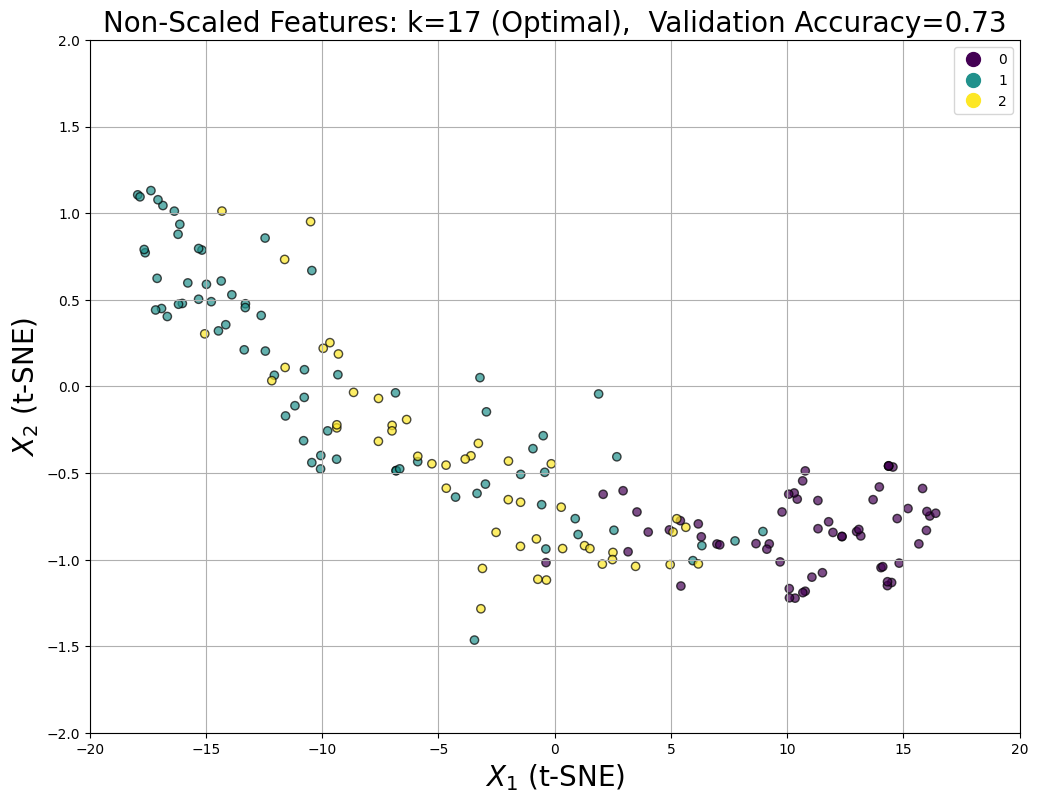

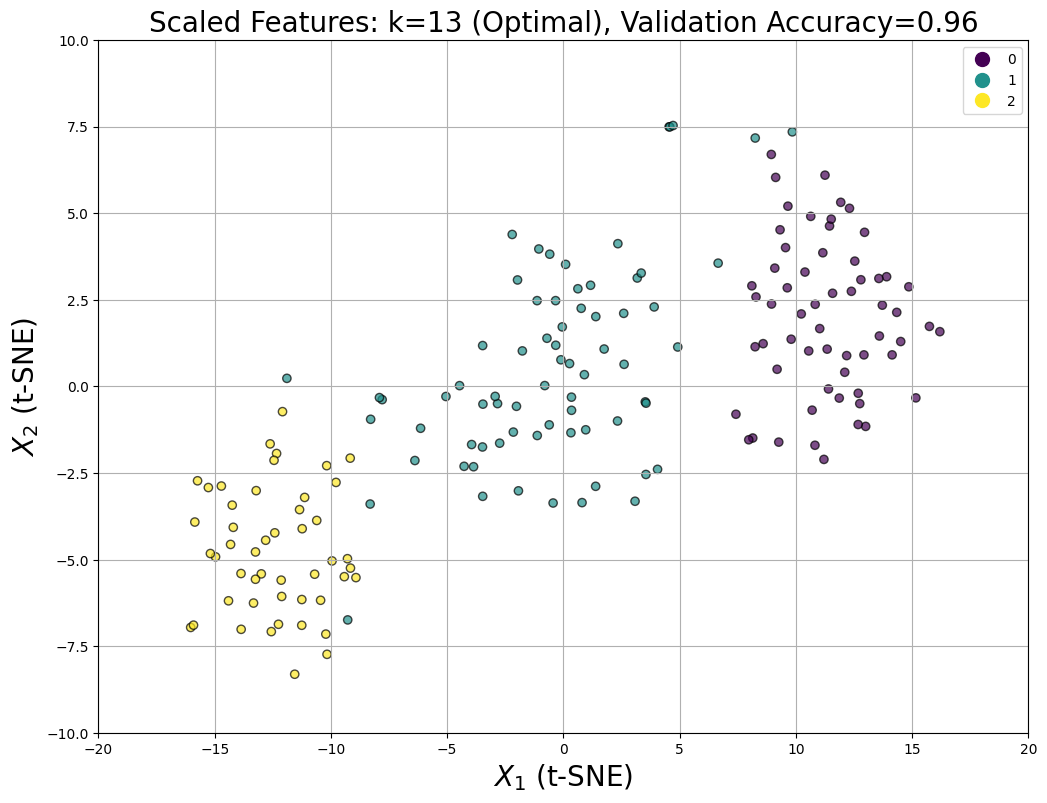

In [ ]:
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target
target_names = data.target_names

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE on the original data
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# t-SNE on the scaled data
tsne_scaled = TSNE(n_components=2, random_state=42)
X_tsne_scaled = tsne_scaled.fit_transform(X_scaled)

# Mapping colors to labels
cmap = plt.cm.viridis
norm = plt.Normalize(y.min(), y.max())

# Figure 1: t-SNE on Original Data
plt.figure(figsize=(12, 9))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap=cmap, edgecolor='k', alpha=0.7, norm=norm)
plt.title('Non-Scaled Features: k=17 (Optimal),  Validation Accuracy=0.73', fontsize=20)
plt.xlabel('$X_1$ (t-SNE)', fontsize=20)
plt.ylabel('$X_2$ (t-SNE)', fontsize=20)
plt.axis([-20, 20, -2, 2])
plt.grid()
# Create a legend:
handles = [plt.Line2D([], [], marker='o', color=cmap(norm(i)), linestyle='', markersize=10, label=name[-1]) for i, name in enumerate(target_names)]
plt.legend(handles=handles)
plt.show()

# Figure 2: t-SNE on Scaled Data
plt.figure(figsize=(12, 9))
scatter = plt.scatter(X_tsne_scaled[:, 0], X_tsne_scaled[:, 1], c=y, cmap=cmap, edgecolor='k', alpha=0.7, norm=norm)
plt.title('Scaled Features: k=13 (Optimal), Validation Accuracy=0.96', fontsize=20)
plt.xlabel('$X_1$ (t-SNE)', fontsize=20)
plt.ylabel('$X_2$ (t-SNE)', fontsize=20)
plt.axis([-20, 20, -10, 10])
plt.grid()
# Create a legend:
handles = [plt.Line2D([], [], marker='o', color=cmap(norm(i)), linestyle='', markersize=10, label=name[-1]) for i, name in enumerate(target_names)]
plt.legend(handles=handles)
plt.show()


In [ ]:
name

NameError: name 'name' is not defined